# ETFs: Feature Engineering

Every model here sees the world through this matrix, so what is computable now bounds what
can be learned later. Each feature answers one question: at the moment a position is decided,
which observations are already on the tape, and what does the feature make of them?

## Learning objectives

- State a feature's timing contract - its lookback and its information lag - before writing
  the code that computes it
- Compute trailing and cross-sectional statistics that read no observation dated after the
  decision timestamp, and declare a lag where an input is not yet available at it
- Show that withholding later dates leaves every feature value unchanged, which is what
  separates a trailing statistic from one fitted over the whole sample
- Read a feature set for scale, dispersion, redundancy and decay before any model sees it

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads split- and dividend-adjusted daily bars via `load_etfs()`,
the Treasury constant-maturity series via `load_macro()`, the tradability gate
`eligibility.csv` from [`01_feasibility_analysis`](01_feasibility_analysis.ipynb), and
`config/setup.yaml`. Writes `features/financial.parquet` with a `.digest.json` sidecar, read by
[`05_evaluation`](05_evaluation.ipynb), which tests fold by fold whether any of it predicts.
[`04_model_based_features`](04_model_based_features.ipynb) builds a second matrix from the same
prices, of features that are themselves model outputs, and `05_evaluation` evaluates the two
together.

In [1]:
"""ETFs: Feature Engineering."""

import logging
import warnings
from datetime import date

import polars as pl
import yaml
from ml4t.engineer.features.momentum import adx, aroon, cci, macd, rsi, stochastic
from ml4t.engineer.features.regime import choppiness_index, hurst_exponent
from ml4t.engineer.features.trend import ema, sma
from ml4t.engineer.features.volatility import bollinger_bands, natr
from ml4t.engineer.features.volume import obv

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.artifact_quality import (
    label_universe,
    quality_report,
    render_quality_report,
)
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    clip_within_date,
    cross_sectional_percentile,
    drawdown_block,
    families_from_config,
    family_coverage,
    momentum_volatility_block,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    rolling_zscore,
    trailing_volume_ratio,
    warmup_audit,
)
from data import load_etfs, load_macro
from utils.artifact_specs import resolve_label_horizon
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")
logging.disable(logging.INFO)

CASE_DIR = get_case_study_dir("etfs")
FEATURES_DIR = CASE_DIR / "features"

The start of the sample is a parameter so the matrix can be rebuilt over a shorter window
without editing the notebook; left unset it reads the whole history.

In [2]:
START_DATE = None

## Configuration

Every window, the ranked feature list, the regime threshold, the decision horizon and the
holdout boundary are declared in `config/setup.yaml` and bound here. A value the notebook
invents is a second source of truth for a decision the rest of the pipeline reads from one
place. The horizon fixes how far the persistence figure has to look, because a feature has to
hold its ordering for at least one decision cycle to be usable at that cadence.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FAMILIES = families_from_config(setup)
WINDOWS = setup["features"]["windows"]
OSCILLATORS = setup["features"]["oscillators"]
STATE = setup["features"]["state"]
RANKED = setup["features"]["ranked"]
REGIME_THRESHOLD = setup["features"]["regime_threshold"]
MACRO_LAG_DAYS = setup["modeling"]["latent_factors"]["macro_context"]["availability_lag_days"]
DECISION_CYCLE = int(resolve_label_horizon("etfs", setup["labels"]["primary"], setup).rstrip("Dd"))
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])

print(f"{len(FAMILIES)} feature families are declared, each with its own lookback and lag")
print(
    f"Positions are re-decided every {DECISION_CYCLE} sessions, so a feature has to hold its "
    f"ordering that long to be usable at this cadence"
)
print(
    f"Dates from {HOLDOUT_START} onward are the holdout; D.3 rebuilds the matrix without them "
    f"and compares the two builds value by value"
)

10 feature families are declared, each with its own lookback and lag
Positions are re-decided every 21 sessions, so a feature has to hold its ordering that long to be usable at this cadence
Dates from 2024-01-01 onward are the holdout; D.3 rebuilds the matrix without them and compares the two builds value by value


## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about persistence: among liquid ETFs spanning
equities, bonds, commodities and currencies, the ones that have gained relative to the rest
continue to over the following month. Three things follow.

What the ranking is formed on is trailing relative performance, so the matrix holds returns
and risk-adjusted returns at eight horizons rather than one - which horizon the effect lives
at is an empirical question, not a modelling assumption. The skip-recent construction drops the
most recent month from the six- and twelve-month windows, because that month reverses where
the ones before it continue.

The **conditioning** is regime: a cross-asset rotation only works while the assets disagree,
so the matrix also carries volatility, drawdown, trend strength, the equity-bond correlation
and the shape of the yield curve. These rank nothing against each other; they say which
environment a ranking is being formed in, which is what the register's `role` column records
and what no assertion can recover from the values.

The **representation** matters as much as the quantity. A raw return has a distribution that
drifts with the volatility of the period, so the three features `config/setup.yaml` lists as
ranked - the six-month return, its risk-adjusted version and the three-month volatility - are
carried as cross-sectional percentiles as well as levels, comparable across dates by
construction.

The register is declared in `config/setup.yaml`, one row per family: what it reads, how far
back, and with what delay. A `lag` of zero means the input is on the tape at the decision
itself, which every price-derived family here is: the decision is taken at the close and
executes at the next open. The yield curve is the one exception, at one session: a Treasury
series dated t is treated as available from the close of t+1, which is what
`config/setup.yaml` declares as the case study's macro policy. That lag is why it is a family
of its own rather than sharing one with the cross-asset correlation, which reads prices.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""momentum""","""signal""","""adjusted close""",252,0,"""time series"""
"""risk-adjusted momentum""","""signal""","""log return""",252,0,"""time series"""
"""volatility""","""state""","""log return""",252,0,"""time series"""
"""oscillator and trend""","""signal""","""OHLC""",200,0,"""time series"""
"""range and drawdown""","""state""","""OHLC""",126,0,"""time series"""
"""volume""","""state""","""share volume""",63,0,"""time series"""
"""extremes and consistency""","""signal""","""adjusted close""",252,0,"""time series"""
"""cross-sectional position""","""signal""","""ret_126d, sharpe_126d, vol_63d""",126,0,"""cross-section"""
"""cross-asset regime""","""state""","""SPY and TLT log returns""",63,0,"""cross-asset"""


## B. Inputs and their observability

Three inputs. Daily bars are split- and dividend-adjusted, so a trailing return spans a
corporate action without a jump. The tradability gate is a table of fund-years written by
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb), which admits a fund to a year on
the turnover it averaged in the year before, so membership is decided by what was already
known and a fund listed in 2019 cannot appear in a 2011 ranking. The 10-year minus 2-year
Treasury spread is the third, and the only input not on the tape at the decision; C.4 says
what is done about that.

In [5]:
prices = (
    load_etfs()
    .select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])
    .sort(["symbol", "timestamp"])
)
if START_DATE is not None:
    prices = prices.filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())

eligibility = pl.read_csv(CASE_DIR / "eligibility.csv")
yield_curve = (
    load_macro()
    .select("timestamp", ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope"))
    .drop_nulls()
    .sort("timestamp")
)
print(
    f"{len(prices):,} daily bars covering {prices['symbol'].n_unique()} of the "
    f"{len(setup['universe']['assets'])} declared funds, {prices['timestamp'].min()} to "
    f"{prices['timestamp'].max()}"
)
print(f"The tradability gate admits {len(eligibility):,} fund-years")
print(
    f"The Treasury spread carries {len(yield_curve):,} rows, one per calendar day from "
    f"{yield_curve['timestamp'].min()} to {yield_curve['timestamp'].max()}, repeating the last "
    f"published value on weekends and holidays"
)

470,662 daily bars covering 100 of the 100 declared funds, 2006-01-03 to 2025-12-31
The tradability gate admits 1,704 fund-years
The Treasury spread carries 9,495 rows, one per calendar day from 2000-01-03 to 2025-12-31, repeating the last published value on weekends and holidays


The longest window below runs over 252 sessions, roughly one trading year, so how much history
a fund brings decides when it can carry a feature at all. Grouping the funds by the year of
their first bar says where that constraint bites. What to read off the table is the split
between the block present from the beginning, which fills every window inside the first year
and never falls out again, and the funds that arrive later, a handful at a time, each of which
spends its own first year producing nulls in the long-window families. That thin tail is what
F1's coverage dips are, what Section E's null policy removes, and why the matrix starts a year
after the price history does.

In [6]:
prices.group_by("symbol").agg(
    pl.col("timestamp").min().alias("first"), pl.len().alias("sessions")
).with_columns(pl.col("first").dt.year().alias("first traded")).group_by("first traded").agg(
    pl.len().alias("funds"),
    pl.col("sessions").min().alias("fewest sessions"),
    pl.col("sessions").median().cast(pl.Int32).alias("median sessions"),
).sort("first traded")

first traded,funds,fewest sessions,median sessions
i32,u32,u32,i32
2006,71,4893,5031
2007,11,4537,4708
2008,3,4468,4468
2009,1,4051,4051
2010,1,4020,4020
2011,3,3570,3570
2012,4,3315,3399
2013,4,3134,3181
2015,1,2573,2573


## C. Feature construction, one subsection per family

### C.1 Momentum, volatility and their differences

The trailing return, volatility and risk-adjusted return block comes from
`case_studies/utils`, shared with the other panel case studies, so `ret_126d` means one
construction and one denominator guard wherever it appears. What stays here is what is
specific to this universe: the skip-recent windows, the differences between horizons, and the
ratio of a short volatility window to a long one. The skip-recent pair counts both its start and
the stretch it drops in the month of sessions `config/setup.yaml` declares, so the month dropped
and the window it is dropped from cannot drift apart.

In [7]:
def momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """The shared trailing block, plus the differences this case study builds on it."""
    df = momentum_volatility_block(
        df,
        entity="symbol",
        return_windows=WINDOWS["momentum"],
        volatility_windows=WINDOWS["volatility"],
    )
    month = WINDOWS["skip_recent"]
    held = pl.col("close").shift(month).over("symbol")
    return df.with_columns(
        (held / pl.col("close").shift(12 * month).over("symbol").clip(lower_bound=EPS) - 1).alias(
            "skip_recent_12_1"
        ),
        (held / pl.col("close").shift(6 * month).over("symbol").clip(lower_bound=EPS) - 1).alias(
            "skip_recent_6_1"
        ),
        (pl.col("ret_21d") - pl.col("ret_63d")).alias("mom_accel_short"),
        (pl.col("ret_63d") - pl.col("ret_126d")).alias("mom_accel_medium"),
        (pl.col("ret_126d") - pl.col("ret_252d")).alias("mom_accel_long"),
        (pl.col("vol_21d") / pl.col("vol_63d").clip(lower_bound=EPS)).alias("vol_ratio_short"),
        (pl.col("vol_63d") / pl.col("vol_126d").clip(lower_bound=EPS)).alias("vol_ratio_medium"),
    )

### C.2 Oscillators, trend ratios and range

Everything in this block reads one fund's price against its own recent path. The
constructions fall into four groups, and a reader who has not met them needs to know what
each measures before the matrix can be read at all.

**Where the price sits inside its recent range.** The relative strength index weighs the
sessions that closed up against those that closed down over its window and reports the result
between 0 and 100, so 50 is a window with as much up movement as down. The stochastic reports
on the same scale where the close sits between the window's lowest low and its highest high.
The commodity channel index measures the same idea without bounds: how far the session's
average of high, low and close sits from that average over the window, in units of the
window's own mean deviation. Bollinger %B is the fourth, and the notebook assembles it from
the bands rather than taking it ready-made: 0 is two standard deviations below the window's
mean close, 1 is two above, and the value is where the close falls between them.

**How strongly the price is trending.** The average directional index summarizes how much of
the session-to-session movement went one way rather than back and forth, without saying which
way, so it separates a trend from a range without taking a side. Aroon counts how recently
the window's high and its low occurred; subtracting the two counts gives one number that is
positive when the high is the more recent. The moving-average convergence-divergence line is
the gap between a fast and a slow exponential average of the close, which widens as a move
accelerates and crosses zero when it turns.

**How far the price moved and how much ground it covered doing so.** The normalized average
true range is the typical session's high-to-low span, counting any overnight gap, as a
percentage of the price - normalizing by price is what makes it comparable across funds
quoted at different levels. The choppiness index divides those spans summed session by session
by the span of the whole window: a market that ends near where it started after covering a lot
of ground reads high, one that travelled in a straight line reads low. The Hurst exponent asks
whether the size of a move grows with the length of the interval faster or slower than
independent increments would give. Above one half, a move tends to be followed by another in
the same direction; below one half, by a reversal; one half is what a random walk gives. It is
estimated by comparing the range of the cumulative move against its dispersion at many
interval lengths at once, which is why it needs a window several times longer than the others
here.

**Where the price sits against its own averages.** The close divided by its 50- and
200-session simple averages and by its 26-session exponential average. Above one, the fund is
trading above that average. Dividing rather than subtracting is what makes the three
comparable across funds, for the same reason the range is normalized by price.

All of them come from `ml4t.engineer.features` rather than being written here. The smoothing
convention inside an oscillator is where two implementations of one name diverge - Wilder's
recursive average and a simple moving average of the same gains give different numbers - and
a shared implementation is what keeps `rsi_14` meaning one thing across the nine case studies.

In [8]:
def oscillator_features(df: pl.DataFrame) -> pl.DataFrame:
    """Bounded oscillators, moving-average ratios, normalized range and regime exponents."""
    adx_p, stoch_p, aroon_p = OSCILLATORS["adx"], OSCILLATORS["stochastic"], OSCILLATORS["aroon"]
    natr_p, chop_p, hurst_p = OSCILLATORS["natr"], OSCILLATORS["choppiness"], OSCILLATORS["hurst"]
    ema_p, bb_p = OSCILLATORS["ema"], OSCILLATORS["bollinger"]
    df = df.with_columns(
        *[rsi("close", period=p).over("symbol").alias(f"rsi_{p}") for p in OSCILLATORS["rsi"]],
        macd("close", fast_period=OSCILLATORS["macd_fast"], slow_period=OSCILLATORS["macd_slow"])
        .over("symbol")
        .alias("macd_line"),
        adx("high", "low", "close", period=adx_p).over("symbol").alias(f"adx_{adx_p}"),
        *[
            cci("high", "low", "close", period=p).over("symbol").alias(f"cci_{p}")
            for p in OSCILLATORS["cci"]
        ],
        stochastic("high", "low", "close", fastk_period=stoch_p).over("symbol").alias("stoch_k"),
        aroon("high", "low", timeperiod=aroon_p).over("symbol").alias("_aroon"),
        natr("high", "low", "close", period=natr_p).over("symbol").alias(f"natr_{natr_p}"),
        choppiness_index("high", "low", "close", period=chop_p)
        .over("symbol")
        .alias(f"chop_{chop_p}"),
        hurst_exponent("close", period=hurst_p).over("symbol").alias(f"hurst_{hurst_p}"),
        *[
            (pl.col("close") / sma("close", period=p).over("symbol")).alias(f"sma_ratio_{p}")
            for p in OSCILLATORS["sma"]
        ],
        (pl.col("close") / ema("close", period=ema_p).over("symbol")).alias(f"ema_ratio_{ema_p}"),
        bollinger_bands("close", period=bb_p).over("symbol").alias("_bb"),
    )
    band = pl.col("_bb").struct.field("upper") - pl.col("_bb").struct.field("lower")
    return df.with_columns(
        (pl.col("_aroon").struct.field("up") - pl.col("_aroon").struct.field("down")).alias(
            "aroon_diff"
        ),
        pl.when(band > 0)
        .then((pl.col("close") - pl.col("_bb").struct.field("lower")) / band)
        .alias(f"bb_pctb_{bb_p}"),
    ).drop(["_aroon", "_bb"])

### C.3 Drawdown, volume and distance from extremes

`max_dd_63d` is the share by which the price currently sits below its highest close of the
trailing quarter, so it is zero at a new high and negative otherwise - the *current*
drawdown, not the worst decline inside the window, which is a different statistic.

On-balance volume is a running total that adds the session's share volume when the fund
closed up and subtracts it when it closed down, so it rises while buying pressure leads and
falls while selling pressure does. The level of that total says nothing on its own, because it
depends on how long the fund has traded and how much it trades; what is carried is its
distance from its own trailing mean in trailing standard deviations, which is comparable
across funds and across time.

The last two read the 52-week extremes directly. The close over its highest close of the past
year is one at a new high and falls away below it; the close over its lowest is one at a new
low and rises above it. The share of the past quarter's sessions that closed up sits beside
them as the same question asked without reference to any extreme.

Relative volume - the session's volume over its own trailing mean - is built with the same
per-fund block, and C.7 says why the extreme values it produces are cut back within the date
rather than here.

In [9]:
def drawdown_and_extremes(df: pl.DataFrame) -> pl.DataFrame:
    """Drawdown, on-balance volume and position in the 52-week range."""
    obv_w, share_w, range_w = STATE["obv_zscore"], STATE["positive_share"], STATE["extremes"]
    df = drawdown_block(df, entity="symbol", windows=WINDOWS["drawdown"])
    df = df.with_columns(obv("close", "volume").over("symbol").alias("_obv"))
    return df.with_columns(
        rolling_zscore("_obv", obv_w, "symbol").alias(f"obv_zscore_{obv_w}d"),
        (pl.col("log_return") > 0)
        .cast(pl.Float64)
        .rolling_mean(share_w)
        .over("symbol")
        .alias(f"pct_positive_{share_w}d"),
        (
            pl.col("close")
            / pl.col("close").rolling_max(range_w).over("symbol").clip(lower_bound=EPS)
        ).alias("dist_52w_high"),
        (
            pl.col("close")
            / pl.col("close").rolling_min(range_w).over("symbol").clip(lower_bound=EPS)
        ).alias("dist_52w_low"),
    ).drop("_obv")

### C.4 Cross-asset state and macro state

The SPY-TLT correlation and the curve slope are one number per date, shared by every ETF. A
rolling window reads row order rather than the timestamp column, so the pair is re-sorted after
the join that builds it, and the curve is joined backward in time so a market holiday carries
the previous session's spread forward and never a later one's.

In [10]:
def equity_bond_correlation(df: pl.DataFrame) -> pl.DataFrame:
    """The trailing SPY-TLT return correlation, one row per date."""
    corr_w = STATE["correlation"]
    return (
        df.filter(pl.col("symbol") == "SPY")
        .select("timestamp", pl.col("log_return").alias("_spy"))
        .join(
            df.filter(pl.col("symbol") == "TLT").select(
                "timestamp", pl.col("log_return").alias("_tlt")
            ),
            on="timestamp",
            how="inner",
        )
        .sort("timestamp")
        .select(
            "timestamp",
            pl.rolling_corr(pl.col("_spy"), pl.col("_tlt"), window_size=corr_w).alias(
                f"corr_spy_tlt_{corr_w}d"
            ),
        )
    )

The Treasury spread is the one input that is not on the tape at the decision: the value
describing a day is published after that day has ended, so a decision taken at its close could
not have read it. `config/setup.yaml` declares the macro policy - `alfred_initial_release_close_lagged`
- and with it how long a published value waits before a decision may use it, and each value is
re-stamped with the date it becomes readable rather than the date it describes. F4 draws the
resulting gap; it is the only family in the register that has one.

The stamped series is then reduced to the trading calendar before the z-score's window runs.
The register counts every family's lookback in trading sessions, and the Treasury frame carries
a row for every calendar day, so a window run over it before that reduction would be counting
weekends.

In [11]:
def yield_curve_state(df: pl.DataFrame) -> pl.DataFrame:
    """Curve level, regime flag and trailing z-score, on the session calendar."""
    zscore_w = STATE["curve_zscore"]
    available = yield_curve.select(
        pl.col("timestamp").dt.offset_by(f"{MACRO_LAG_DAYS}d"), "slope"
    ).sort("timestamp")
    return (
        df.select("timestamp")
        .unique()
        .sort("timestamp")
        .join_asof(available, on="timestamp", strategy="backward")
        .select(
            "timestamp",
            pl.when(pl.col("slope") > REGIME_THRESHOLD).then(1).otherwise(0).alias("regime"),
            pl.col("slope").alias("yield_curve_slope"),
            (
                (pl.col("slope") - pl.col("slope").rolling_mean(zscore_w))
                / pl.col("slope").rolling_std(zscore_w).clip(lower_bound=EPS)
            ).alias("yield_curve_zscore"),
        )
    )

Both state frames carry one row per date, so a left join broadcasts each to every ETF trading
that day without changing the panel's row count.

In [12]:
def regime_and_state(df: pl.DataFrame) -> pl.DataFrame:
    """Equity-bond correlation and yield-curve state, broadcast to every row."""
    return (
        df.join(equity_bond_correlation(df), on="timestamp", how="left")
        .join(yield_curve_state(df), on="timestamp", how="left")
        .sort(["symbol", "timestamp"])
    )

### C.5 The tradability gate

`01_feasibility_analysis` decided, one fund-year at a time, which ETFs traded at enough volume
to be worth ranking. Applying that here is a semi-join on the row's own calendar year, which
filters and cannot duplicate a row.

In [13]:
def gate_to_eligible(df: pl.DataFrame) -> pl.DataFrame:
    """Drop the rows the annual tradability gate excludes, before anything ranks them."""
    return (
        df.with_columns(pl.col("timestamp").dt.year().alias("_year"))
        .join(
            eligibility.select("symbol", pl.col("eligible_year").alias("_year")),
            on=["symbol", "_year"],
            how="semi",
        )
        .drop("_year")
    )

### C.6 What is computable before the gate

None of the four blocks above needs the eligible cross-section: three read one fund's own
history, and the fourth reads two named funds and the Treasury series and broadcasts one value
per date. So they all run on every bar the ETF traded, before the gate removes any. The
relative-volume ratio runs in this group for the same reason:
its trailing mean has to see every bar, or a fund admitted to the universe this year divides by
the mean of its first few eligible days, and one that re-enters after a gap averages across the
gap.

In [14]:
def per_entity_features(df: pl.DataFrame) -> pl.DataFrame:
    """Everything computable before the gate: per-fund history plus the broadcast state."""
    return (
        df.pipe(momentum_features)
        .pipe(oscillator_features)
        .pipe(drawdown_and_extremes)
        .pipe(regime_and_state)
        .pipe(trailing_volume_ratio, entity="symbol", windows=WINDOWS["volume"])
    )

### C.7 The two steps taken within a date

A percentile and a clip are properties of the cross-section they are taken over, so both run
after the gate: ranking an ETF against one the strategy cannot trade moves the number written
for every ETF that it can. Which features are carried as their percentile within the date as
well as their level is `config/setup.yaml`'s `ranked` list, so the same ones are ranked in
every stage that reads the register.

The clip cuts relative volume back to the 1st and 99th percentile of its own date. An index
rebalance puts one fund's volume orders of magnitude above its own trailing mean for a single
session, and one such row otherwise sets the scale every model sees for the whole column.
Cutting within the date rather than over the column is what keeps the bound from being fitted
on the sample, which is the property D.3 checks.

In [15]:
def clip_and_rank(df: pl.DataFrame) -> pl.DataFrame:
    """The two within-date steps, over the eligible cross-section only."""
    clipped = clip_within_date(
        df, columns=[f"vol_ratio_{w}d" for w in WINDOWS["volume"]], time="timestamp"
    )
    return clipped.with_columns(
        cross_sectional_percentile(col, "timestamp").alias(f"{col}_rank") for col in RANKED
    )

### C.8 The construction as one function

The three groups run in that order - per entity, then the gate, then within the date - and
wrapping them in one function is what lets D.3 re-run the identical construction on a shorter
panel and compare the results value by value.

In [16]:
def build_features(df: pl.DataFrame) -> pl.DataFrame:
    """The whole construction, as one function Section D can re-run on a shorter panel."""
    return df.pipe(per_entity_features).pipe(gate_to_eligible).pipe(clip_and_rank)

The panel is built once here in two stages, because D.2 audits the warmup on the ungated frame:
the gate drops the early rows the warmup stretch is made of.

In [17]:
EXCLUDED = {"symbol", "timestamp", "open", "high", "low", "close", "volume", "log_return"}
per_entity = per_entity_features(prices)
built = per_entity.pipe(gate_to_eligible).pipe(clip_and_rank)
feature_cols = [c for c in built.columns if c not in EXCLUDED]
print(f"{len(built):,} eligible bars carrying {len(feature_cols)} features")

404,500 eligible bars carrying 57 features


## D. The timing contract

### D.1 What each construction reads

Three kinds of operation appear above. A **rolling** window ends at its own row and reads a
fixed number of bars backward. A **cross-sectional** statistic - the three percentiles, and
the volume clip - is taken with `.over("timestamp")`, so it reads every ETF on that date and
no other. An **as-of join** carries the most recent macro value at or before the row's
timestamp. D.2 and D.3 establish that none of the three reaches forward.

### D.2 Warmup

A trailing window cannot produce a value until it has enough bars to fill, so every family has
a leading stretch of nulls as long as its lookback. The audit checks that length rather than
describing it: a column carrying a value before its window could have filled is reading bars
that do not exist, and that is the failure it raises on. It runs on the panel before the
eligibility gate, because the gate drops the early rows the warmup stretch is made of. The
lengths it checks are the declared windows themselves, so each column is audited against the
number its own construction ran on.

In [18]:
longest_return = max(WINDOWS["momentum"])
longest_vol = max(WINDOWS["volatility"])
longest_drawdown = max(WINDOWS["drawdown"])
trend_slow, hurst_p, obv_w = max(OSCILLATORS["sma"]), OSCILLATORS["hurst"], STATE["obv_zscore"]
warmup_audit(
    per_entity,
    {
        f"ret_{longest_return}d": longest_return,
        "skip_recent_12_1": 12 * WINDOWS["skip_recent"],
        f"sharpe_{longest_return}d": longest_return,
        f"vol_{longest_vol}d": longest_vol,
        "dist_52w_high": STATE["extremes"],
        f"sma_ratio_{trend_slow}": trend_slow,
        f"max_dd_{longest_drawdown}d": longest_drawdown,
        f"hurst_{hurst_p}": hurst_p,
        f"obv_zscore_{obv_w}d": obv_w,
    },
    entity="symbol",
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""ret_252d""",252,253,true
"""skip_recent_12_1""",252,253,true
"""sharpe_252d""",252,253,true
"""vol_252d""",252,253,true
"""dist_52w_high""",252,252,true
"""sma_ratio_200""",200,200,true
"""max_dd_126d""",126,126,true
"""hurst_100""",100,100,true
"""obv_zscore_63d""",63,63,true


### D.3 Withholding the holdout changes nothing

Trailing and within-date statistics share a property worth checking directly: recomputed on a
panel that stops before the holdout, they reproduce the same values on the rows the two panels
share. A parameter fitted over a whole column - a winsorization bound, a scaler, an encoder -
does not, because truncating the column moves the parameter and with it every row it was
applied to. Building the panel twice and comparing tests the whole construction at once -
every emitted column, not a sample - and does not depend on anyone having flagged the
transform that fits. A value on one side against a null on the other counts as a difference,
because that is the form of the failure a null-skipping comparison hides.

In [19]:
seal = assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(prices.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=feature_cols,
    keys=["timestamp", "symbol"],
)
seal.filter(pl.col("column").is_in(["ret_126d", "ret_126d_rank", "yield_curve_zscore"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""ret_126d""",357564,0,0.0
"""yield_curve_zscore""",357564,0,0.0
"""ret_126d_rank""",357564,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Raw OHLC, volume and the intermediate log return are
excluded: they are the inputs the features are made of, and a model handed the contemporaneous
log return beside a label derived from the same prices would be reading its own answer. One
null policy is applied once - a row is kept when the six-month risk-adjusted return has warmed
up. Most of the warmup stretch is already gone by then, because the eligibility gate admits a
fund only from its second year, so what stays thin is the 252-session families, and F1 shows
where.

In [20]:
features = (
    built.select(["timestamp", "symbol", *feature_cols])
    .drop_nulls(subset=["sharpe_126d"])
    .sort(["timestamp", "symbol"])
)
assert features.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, "duplicate panel key"
assignment = assign_families(feature_cols, FAMILIES)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

family,columns,role,representation
str,i64,str,str
"""momentum""",13,"""signal""","""simple return, and differences…"
"""risk-adjusted momentum""",8,"""signal""","""window return over its own dis…"
"""volatility""",6,"""state""","""annualized standard deviation,…"
"""oscillator and trend""",12,"""signal""","""bounded oscillator, ratio to a…"
"""range and drawdown""",5,"""state""","""normalized range, Hurst expone…"
"""volume""",3,"""state""","""ratio to trailing mean, z-scor…"
"""extremes and consistency""",3,"""signal""","""ratio to a rolling extreme, sh…"
"""cross-sectional position""",3,"""signal""","""percentile within the decision…"
"""cross-asset regime""",1,"""state""","""rolling correlation"""


### F1. Coverage through time

The axis is scaled to the data, not pinned to zero: this matrix is dense everywhere, and on a
zero-based axis every family would draw as one flat line at the top. What is left to see is
where the residual percent sits, and it sits in the families with the longest windows - an ETF
admitted by the eligibility gate partway through a year has not yet filled a 252-session
lookback.

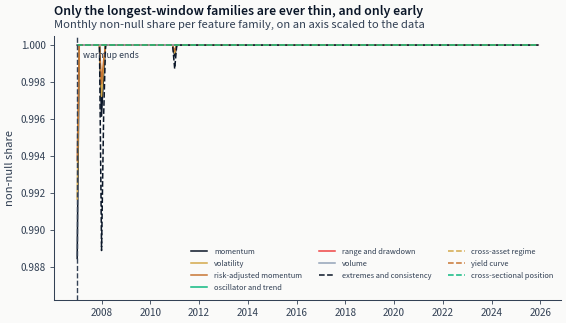

In [21]:
plot_coverage_through_time(
    family_coverage(features, assignment, every="1mo"),
    warmup_boundary=features["timestamp"].min(),
    title="Only the longest-window families are ever thin, and only early",
    subtitle="Monthly non-null share per feature family, on an axis scaled to the data",
    alt=(
        "Line chart of non-null share by feature family on a y-axis that starts at about 0.985 "
        "and ends just above one. Six of the ten families sit exactly at one throughout. The "
        "four that do not - "
        "extremes and consistency, momentum, volatility, risk-adjusted momentum, all built on "
        "252-session windows - dip in three or four months before 2012 and nowhere else, the "
        "deepest to about 0.987, and no family is ever materially incomplete."
    ),
)

### F4. The timing contract

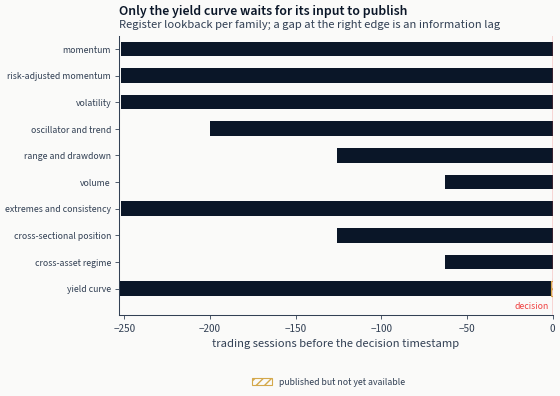

In [22]:
plot_timing_contract(
    FAMILIES,
    bar_unit="trading sessions",
    title="Only the yield curve waits for its input to publish",
    subtitle="Register lookback per family; a gap at the right edge is an information lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line by that family's lookback, from 63 sessions for volume and the cross-asset "
        "correlation to 252 for momentum and the yield curve. Every bar reaches the decision "
        "line except the yield curve, which stops one session short of it."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives
on, whether the cross-section disagrees enough to rank on, how much of the set is one ordering
under several names, and how long a value lasts. `05_evaluation` is where the matrix is tested
fold by fold for whether any of it predicts.

### F2. Feature distributions

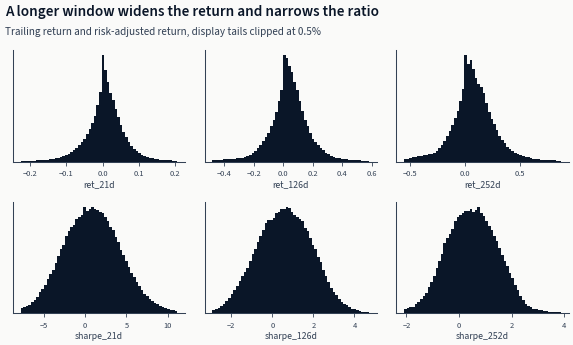

In [23]:
plot_feature_distributions(
    features,
    ["ret_21d", "ret_126d", "ret_252d", "sharpe_21d", "sharpe_126d", "sharpe_252d"],
    title="A longer window widens the return and narrows the ratio",
    subtitle="Trailing return and risk-adjusted return, display tails clipped at 0.5%",
    alt=(
        "Six histograms in two rows. Along the top the trailing returns broaden from a narrow "
        "spike spanning about minus 0.22 to 0.21 at 21 sessions to a wide body running from "
        "about minus 0.55 to 0.88 at 252, every one of them sharply peaked with long tails "
        "either side. Below, the annualized risk-adjusted returns move the other way, from "
        "roughly minus eight to eleven at 21 sessions in to about minus two to four at 252, "
        "and all three are broad single-peaked bells rather than spikes."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band
narrows to nothing there is nothing to rank, whatever the average level of the feature.

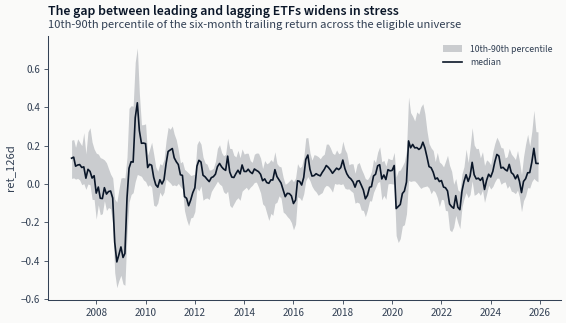

In [24]:
plot_cross_sectional_dispersion(
    features,
    "ret_126d",
    every="1mo",
    title="The gap between leading and lagging ETFs widens in stress",
    subtitle="10th-90th percentile of the six-month trailing return across the eligible universe",
    alt=(
        "Shaded band of the 10th to 90th percentile of six-month trailing return by month, with "
        "the median drawn through it. In most months the band is between about 0.15 and 0.30 "
        "wide. It is widest through 2008 and 2009, reaching about 0.62, when the median also "
        "falls to about minus 0.4, and it widens again to about 0.44 in 2020. The 2022 widening "
        "is smaller, about 0.34, and more than a tenth of all months are at least that wide."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering, whatever
the sign. Above the cut two features are close enough that a linear model cannot separate
their contributions. This states the clusters and stops there: `05_evaluation` measures each
feature's predictive content fold by fold and reports which pairs are one piece of evidence
counted twice, and the modelling notebooks decide what to keep.

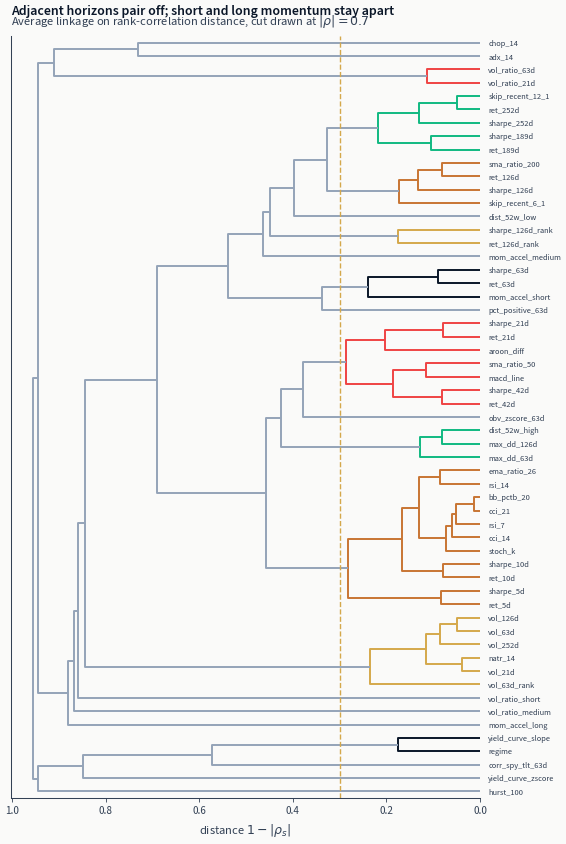

In [25]:
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=0.7,
    title="Adjacent horizons pair off; short and long momentum stay apart",
    subtitle=r"Average linkage on rank-correlation distance, cut drawn at $|\rho| = 0.7$",
    alt=(
        "Dendrogram of every feature in the matrix. Neighbouring horizons join at very small "
        "distances - the five- and ten-day returns with their risk-adjusted twins, the six-month "
        "return with its risk-adjusted twin, its skip-recent version and the 200-day trend ratio "
        "- and the bounded oscillators join that shortest-horizon block rather than standing "
        "apart from it. The nine- and twelve-month returns form a block of their own that stays "
        "separate from the six-month one at the cut and joins it only further out; the "
        "short-horizon and long-horizon blocks join later still. Volatility and the macro "
        "features attach as separate branches."
    ),
)

### F6. Persistence and rank stability

The right-hand panel compares the ordering across consecutive **rebalances**, which
`config/setup.yaml` declares as `monthly_month_end` - a varying number of sessions apart, so
a fixed lag would correlate dates the strategy never puts side by side.

The autocorrelation on the left is of the feature, not of the return, and it runs past one
full decision cycle. A feature whose value has decayed inside a cycle cannot support that
rebalance cadence, however well it predicts on the day it is computed. It is estimated per ETF
on pairs of dates exactly one lag apart and summarized by the median over ETFs, with a
bootstrap interval over ETFs: a correlation pooled over every ETF-date pair would read high
whenever ETFs sit at different levels, whether or not any one of them persists.

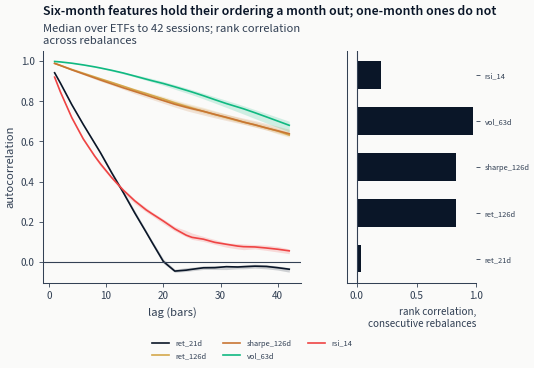

In [26]:
DECISION_DATES = (
    features.group_by(pl.col("timestamp").dt.truncate("1mo"))
    .agg(pl.col("timestamp").max().alias("decision"))["decision"]
    .sort()
    .to_list()
)

plot_persistence(
    features,
    ["ret_21d", "ret_126d", "sharpe_126d", "vol_63d", "rsi_14"],
    entity="symbol",
    max_lag=2 * DECISION_CYCLE,
    decision_dates=DECISION_DATES,
    title="Six-month features hold their ordering a month out; one-month ones do not",
    subtitle=(
        f"Median over ETFs to {2 * DECISION_CYCLE} sessions; rank correlation across rebalances"
    ),
    alt=(
        "Two panels. On the left, autocorrelation against lag: the six-month return, the "
        "three-month volatility and the six-month risk-adjusted return decay slowly and are all "
        "still above 0.6 at 42 sessions, while the one-month return reaches zero at about 21 "
        "sessions - the length of its own window - and the 14-day oscillator falls below 0.1. The "
        "bootstrap ribbon around each curve is only a few hundredths wide. On the right, the "
        "cross-sectional rank correlation between consecutive rebalances separates the features "
        "sharply: about 0.98 for the three-month volatility and 0.83 for the two six-month "
        "features, against 0.2 for the oscillator and almost nothing for the one-month return, "
        "whose window is about one rebalance long."
    ),
)

## G. Emit

The matrix goes to a parquet file, and beside it a small JSON file records what was written.
Its purpose is to let a later stage tell whether the matrix it is reading is the one it was
tested against, without re-reading the whole file: it holds a digest of the values, the row
count, the key columns, and the digest of each input this notebook read.

A digest is a short string computed from the contents, so that two files holding the same
values get the same string and any change in a value gets a different one. Computing it over
the values rather than over the bytes of the file is what makes it usable here: rewriting the
parquet with the rows in another order, or with different compression, leaves the digest
alone, while a single corrected feature value moves it. Recording the inputs' digests
alongside it is what makes the record a chain - a downstream stage can see not only that the
matrix changed but that it changed because its input did.

In [27]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=["symbol", "timestamp"],
    written_by="case_studies/etfs/03_financial_features.py",
    inputs={
        "eligibility.csv": value_digest(eligibility),
        "load_etfs": value_digest(prices),
        "load_macro:dgs10-dgs2": value_digest(yield_curve),
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}")

Wrote case_studies/etfs/features/financial.parquet


The matrix carries **57 features** on **404,500 rows** across **99 ETFs**, from **2007-01-03**
to **2025-12-31**, under content digest **9c02a41ef4364257**. Cutting the redundancy tree
leaves **22 clusters**, so well over half the columns repeat an ordering another column
already carries.

In [28]:
print(f"{len(feature_cols)} features, {len(features):,} rows, {features['symbol'].n_unique()} ETFs")
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, digest {record['digest']}")
print(f"{len(set(clusters.values()))} redundancy clusters")

57 features, 404,500 rows, 99 ETFs
2007-01-03 to 2025-12-31, digest 9c02a41ef4364257
22 redundancy clusters


## What the matrix holds, and what it owes

Two questions about the file this stage just wrote. The first is what is in each column - nulls,
how much sits at exactly zero, how far the extreme values are from the body, whether anything is
constant. A threshold crossed there asks for a sentence of explanation and settles nothing on
its own: a 45% null share is a defect in a price and expected in a 252-session family on a fund
with three years of history.

The second is the question a null count cannot reach. **Coverage is measured against the keys
the labels declare, not against the rows this matrix happens to hold.** A matrix emitting a
thousand rows where a million were owed carries no nulls at all and is wrong; nothing inside it
can say so, because the missing rows are not there to be counted. The labels are the right
reference because a `(symbol, timestamp)` carrying a label and no feature row is one no model can
be asked to score - it is lost to every family at once, before any of them is fitted.

And a shortfall against that reference is not by itself a defect, so the matrix declares where
it is entitled to be short before the number is printed. Two mechanisms decide it and only one
of them is a window. The null policy keeps a row when the six-month risk-adjusted return has
warmed up, which costs `sharpe_126d`'s window. **The eligibility gate costs far more, and it
costs a different amount per fund**: it is annual and admits a fund only for the years it
cleared, so a fund that listed early and grew slowly loses years at the front, one that lost
liquidity mid-life loses a stretch out of the middle, and one that never cleared loses
everything. None of that is a session count, so the declaration below names the mechanism
without pretending to bound it, and the check after it is what makes the declaration worth
having: every missing key is tested against the fund-years the gate actually admitted.

In [29]:
LEADING_BUDGET = WINDOWS["volatility"][2]
print(f"warmup budget {LEADING_BUDGET} sessions = the sharpe_126d window the null policy keeps on")

report = quality_report(
    features,
    name="financial features",
    key_columns=["symbol", "timestamp"],
    expected=label_universe(CASE_DIR, keys=["symbol", "timestamp"]),
    keys=["symbol", "timestamp"],
    entity="symbol",
    session="timestamp",
    expected_missing={
        "leading": (
            None,
            "the eligibility gate's first admitted year, then the 126-session warmup",
        ),
        "interior": (None, "a year the eligibility gate did not admit"),
        "trailing": (None, "a year the eligibility gate did not admit"),
        "absent": (None, "a fund the eligibility gate never admitted"),
    },
)
render_quality_report(report)

warmup budget 126 sessions = the sharpe_126d window the null policy keeps on


=== financial features ===
coverage 85.93%: 404,500 of 470,162 declared keys, 66,132 missing, 470 unexpected
where the missing keys sit, and what accounts for them:
┌──────────┬────────┬───────────┬───────────┬───────────┬────────┬───────────┬──────────┬──────────┐
│ where    ┆ n_keys ┆ n_entitie ┆ sessions_ ┆ sessions_ ┆ budget ┆ entities_ ┆ excess_k ┆ why      │
│ ---      ┆ ---    ┆ s         ┆ p50       ┆ max       ┆ ---    ┆ over      ┆ eys      ┆ ---      │
│ str      ┆ i64    ┆ ---       ┆ ---       ┆ ---       ┆ null   ┆ ---       ┆ ---      ┆ str      │
│          ┆        ┆ i64       ┆ f64       ┆ i64       ┆        ┆ i64       ┆ i64      ┆          │
╞══════════╪════════╪═══════════╪═══════════╪═══════════╪════════╪═══════════╪══════════╪══════════╡
│ absent   ┆ 5026   ┆ 1         ┆ 5026.0    ┆ 5026      ┆ null   ┆ 0         ┆ 0        ┆ a fund   │
│          ┆        ┆           ┆           ┆           ┆        ┆           ┆          ┆ the elig │
│          ┆        ┆      

Four declarations, one mechanism, and one check for all four. A key is owed a feature row only
when the gate admitted that fund for that key's year *and* the warmup has passed inside it; every
other missing key is the gate, wherever in a fund's life it happens to fall. Testing it against
the gate's own table is the whole point - the shape of the loss looks like four different
problems and is one.

In [30]:
admitted = eligibility.select("symbol", pl.col("eligible_year").alias("_year"))
missing = report["missing_classified"].with_columns(pl.col("timestamp").dt.year().alias("_year"))
outside = missing.join(admitted, on=["symbol", "_year"], how="anti")
print(
    f"of {missing.height:,} missing keys, {outside.height:,} "
    f"({outside.height / missing.height:.2%}) fall in a fund-year the gate did not admit"
)
inside = missing.join(admitted, on=["symbol", "_year"], how="semi")
if inside.height:
    per_fund = inside.group_by("symbol").len().sort("len", descending=True)
    print(
        f"  {inside.height:,} key(s) across {per_fund.height} fund(s) sit in an admitted year; "
        f"worst fund short {per_fund['len'].max()} session(s), median {int(per_fund['len'].median())}"
    )

of 66,132 missing keys, 66,132 (100.00%) fall in a fund-year the gate did not admit


### Sign-off

**Coverage is 85.93% - 404,500 of the 470,162 keys the labels declare - and every one of the
66,132 missing keys falls in a fund-year the eligibility gate did not admit.** Not most of them,
and not most of them after a warmup is subtracted: all of them. The gate is annual, so a fund
enters the matrix in the first year it cleared and leaves in any year it did not, and the shape
that produces looks like four separate problems until it is tested against the gate's own table -
46,795 keys before a fund's first feature row, 10,319 inside eleven funds' spans, 3,992 after
five funds' last row, and one fund with no row at all. One mechanism, four positions, nothing
else.

The 126-session warmup the null policy applies is real but almost invisible here, because the
gate has already removed the stretch it would have taken: a fund is admitted from a year in which
it was already liquid, by which point its six-month window has long since filled. That is why the
budget is printed and then not needed, and it is worth seeing rather than assuming - a warmup
that *was* biting would show as keys inside an admitted year, and there are none.

**470 keys carry a feature row and no label**, the mirror case, at 0.1% of the matrix. A feature
row with no label is never joined, so it is carried rather than dropped.


## Key takeaways

- **State the timing contract before writing the feature.** The configuration fixes each family's
  lookback and lag in the register and every window the construction runs, so the timing figure
  and the warmup assertion read those declarations rather than numbers retyped in the code.
- **Check that later dates were not read, by rebuilding rather than by inspecting.**
  Constructing the panel a second time with the holdout withheld and comparing the two value
  by value catches any transform that fits across the sample, including the ones nobody
  thought to flag.
- **Rank inside the date.** A percentile taken within one timestamp is comparable across dates
  in a way a raw level, whose distribution drifts with the period's volatility, is not.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- The cross-asset regime feature is one pair, SPY against TLT. It describes the equity-bond
  relationship and says nothing about the commodity and currency funds the universe also
  holds.
- The eligibility gate is annual, so an ETF that lost liquidity in June stays in the
  cross-section until December.
- The yield-curve features carry the configured one-session availability lag, but they read
  the revised Treasury history rather than the initial release. A value revised later is not
  the value the decision could have seen, whatever its timestamp says.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.